In [1]:
%matplotlib inline

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from astropy.io import fits
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from tensorflow import keras
import keras_tuner as kt

I0000 00:00:1787342356.296359   87060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787342356.439730   87060 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787342357.528620   87060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# TensorFlow setup

In [3]:
# Check if TensorFlow detects any GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Success! TensorFlow detected {len(gpus)} GPU(s): {gpus}")

    # This prevents TensorFlow from instantly reserving all GPU VRAM
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("Warning: No GPU detected. TensorFlow will fall back to the CPU.")

Success! TensorFlow detected 1 GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


# Data reading and preprocessing

In [8]:
def load_and_preprocess_regression_data(data_dir, csv_path, filename_col, ba_col, ca_col):
    """
    Reads FITS files and regression targets.
    Transforms raw b/a and c/a targets into Triaxiality and Ellipticity.
    Applies global robust scaling to preserve physical scales.
    """
    df = pd.read_csv(csv_path)

    raw_images = []
    targets = []

    print("Reading FITS files and re-parameterizing targets...")
    for index, row in df.iterrows():
        filename = row[filename_col]

        # Extract raw values
        ba_val = float(row[ba_col])
        ca_val = float(row[ca_col])

        # 1. Calculate Triaxiality (T)
        # Adding a tiny epsilon (1e-7) to the denominator prevents division by zero
        # in perfectly spherical cases where c/a = 1.0
        triaxiality = (1.0 - ba_val**2) / (1.0 - ca_val**2 + 1e-7)
        triaxiality = np.clip(triaxiality, 0.0, 1.0) # Ensure strict [0, 1] bounds

        # 2. Calculate Intrinsic Ellipticity (Epsilon)
        ellipticity = 1.0 - ca_val

        # New target array for the CNN
        target_vals = [triaxiality, ellipticity]

        filepath = os.path.join(data_dir, filename)

        with fits.open(filepath) as hdul:
            data = hdul[0].data  # Expected shape: (3, 69, 69)

        # Handle NaNs and apply individual scaling for each channel
        for i in range(3):
            channel_data = data[i, :, :]
            mean_val = np.nanmean(channel_data)
            if np.isnan(mean_val):
                mean_val = 0.0
            channel_data[np.isnan(channel_data)] = mean_val

            # Scale by the maximum absolute value in the channel
            # channel_data = channel_data / np.nanmax(np.abs(channel_data))

            data[i, :, :] = channel_data

        # Transpose to (Height, Width, Channels) -> (69, 69, 3)
        data = np.transpose(data, (1, 2, 0))
        raw_images.append(data)
        targets.append(target_vals)

    X = np.array(raw_images, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)

    return X, y

In [9]:
def reconstruct_axis_ratios(predictions):
    """
    Utility function to convert the CNN's predictions of [Triaxiality, Ellipticity]
    back into the original [b/a, c/a] physical axis ratios.

    predictions: numpy array of shape (N, 2) where col 0 is Triaxiality, col 1 is Ellipticity
    returns: numpy array of shape (N, 2) containing [b/a, c/a]
    """
    pred_triax = predictions[:, 0]
    pred_ellip = predictions[:, 1]

    # Reconstruct c/a = 1 - ellipticity
    reconstructed_ca = 1.0 - pred_ellip

    # Reconstruct b/a = sqrt(1 - T * (1 - (c/a)^2))
    # Using np.clip to prevent negative values inside sqrt due to network noise
    inner_term = 1.0 - pred_triax * (1.0 - reconstructed_ca**2)
    reconstructed_ba = np.sqrt(np.clip(inner_term, 0.0, 1.0))

    # Stack back together into (N, 2)
    return np.column_stack((reconstructed_ba, reconstructed_ca))

In [10]:
DATA_DIRECTORY = "./VELOCITY_VDISP_FLUX_MAPS"
CSV_FILE_PATH = "./files_list_and_axis.csv"
FILENAME_COLUMN_NAME = "filename"
BA_COLUMN_NAME = "b_a"
CA_COLUMN_NAME = "c_a"

In [11]:
X, y = load_and_preprocess_regression_data(
    data_dir=DATA_DIRECTORY,
    csv_path=CSV_FILE_PATH,
    filename_col=FILENAME_COLUMN_NAME,
    ba_col=BA_COLUMN_NAME,
    ca_col=CA_COLUMN_NAME
)

Reading FITS files and re-parameterizing targets...


In [12]:
def plot_random_galaxy_kinematics(X):
    """
    Randomly selects a galaxy from X and plots its 3 kinematic maps
    (Flux, Velocity, Dispersion)
    """
    idx = np.random.randint(len(X))
    galaxy = X[idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(galaxy[:, :, 0], cmap='magma', origin='lower')
    axes[0].set_title('Flux')
    fig.colorbar(im0, ax=axes[0])

    v_max = np.max(np.abs(galaxy[:, :, 1]))
    if v_max == 0:
        v_max = 1.0
    im1 = axes[1].imshow(galaxy[:, :, 1], cmap='RdBu_r', origin='lower', vmin=-v_max, vmax=v_max)
    axes[1].set_title('Velocity')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(galaxy[:, :, 2], cmap='plasma', origin='lower')
    axes[2].set_title('Velocity Dispersion')
    fig.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

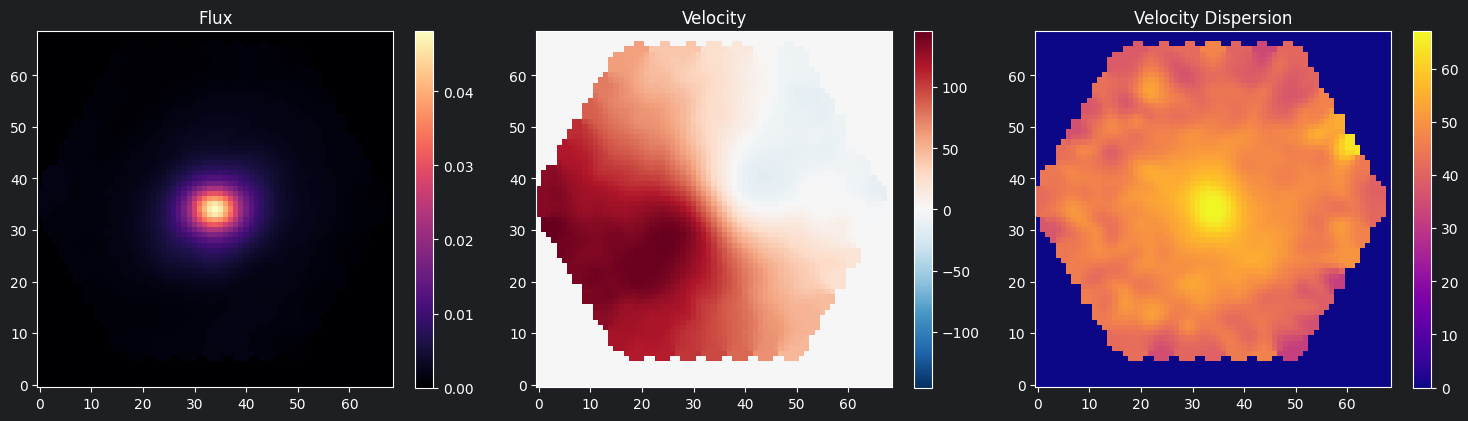

In [13]:
plot_random_galaxy_kinematics(X)

# Setting weights to the trainig set

In [14]:
def compute_sample_weights(y):
    """
    Calculates sample weights based on the 2D density of the targets.
    Rare (b/a, c/a) combinations will receive higher weights.
    """
    print("Calculating 2D Kernel Density for sample weighting...")

    # Transpose y for KDE: needs shape (2, num_samples)
    values = y.T

    # Calculate the density of the parameter space using Gaussian KDE
    kde = gaussian_kde(values)
    density = kde.evaluate(values)

    # Inverse density weighting: rarer points get higher weights
    # add a small constant (epsilon) to prevent division by zero or infinite weights
    epsilon = np.percentile(density, 5) # Prevent extreme spikes for utter outliers
    weights = 1.0 / (density + epsilon)

    weights = weights / np.mean(weights)

    return weights.astype(np.float32)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_weights = compute_sample_weights(y_train)

Calculating 2D Kernel Density for sample weighting...


Text(0.5, 1.0, 'Training Set Density Weighting')

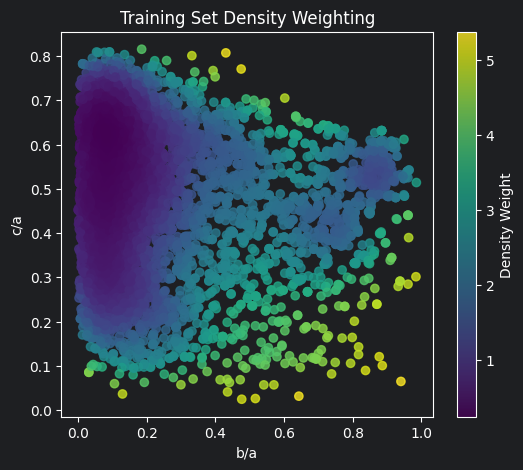

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
axes.scatter(y_train[:,0], y_train[:,1], alpha=0.8, c=train_weights)
axes.set_xlabel("b/a")
axes.set_ylabel("c/a")
fig.colorbar(mappable=axes.get_children()[0], ax=axes, label="Density Weight")

axes.set_title("Training Set Density Weighting")

# CNN design

In [17]:
@tf.keras.utils.register_keras_serializable(package="Custom") # Needed to save/load model
class PearsonHuberLoss(tf.keras.losses.Loss):
    """
    Combines Huber Loss (robust point-wise distance) with Pearson Correlation Loss.
    Pearson Correlation Loss penalizes regression-to-the-mean (horizontal flattening)
    by forcing predictions to maintain linear correlation with true values.
    """
    def __init__(self, alpha=0.25, delta=0.1, name="pearson_huber_loss", reduction="sum_over_batch_size"):
        super().__init__(name=name, reduction=reduction)
        self.alpha = alpha
        self.delta = delta
        self.huber = tf.keras.losses.Huber(delta=delta, reduction=reduction)

    def call(self, y_true, y_pred):
        # Huber Loss (Point-wise error)
        h_loss = self.huber(y_true, y_pred)

        # Pearson Correlation Loss across the current batch
        y_true_mean = tf.reduce_mean(y_true, axis=0, keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=0, keepdims=True)

        y_true_centered = y_true - y_true_mean
        y_pred_centered = y_pred - y_pred_mean

        covariance = tf.reduce_sum(y_true_centered * y_pred_centered, axis=0)
        var_true = tf.reduce_sum(tf.square(y_true_centered), axis=0)
        var_pred = tf.reduce_sum(tf.square(y_pred_centered), axis=0)

        # Small epsilon to prevent division by zero
        std_product = tf.sqrt(var_true * var_pred + 1e-7)
        pearson_r = covariance / std_product

        p_loss = tf.reduce_mean(1.0 - pearson_r)

        return h_loss + self.alpha * p_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha,
            "delta": self.delta
        })
        return config

In [18]:
def build_regression_model(input_shape=(69, 69, 3)):
    l2_reg = tf.keras.regularizers.l2(1e-5)

    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.RandomFlip("horizontal_and_vertical"),

        tf.keras.layers.DepthwiseConv2D(
            kernel_size=(3, 3),
            depth_multiplier=8,
            activation='relu',
            padding='same',
            depthwise_regularizer=l2_reg
        ),
        tf.keras.layers.Conv2D(32, (1, 1), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2_reg),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3),

        # Activation is 'sigmoid' which forces the output
        # to always be strictly between 0.0 and 1.0.
        tf.keras.layers.Dense(2, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
        loss=PearsonHuberLoss(alpha=0.25, delta=0.1),
        metrics=['mae']
    )

    return model

# Model training

In [19]:
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, train_weights))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1787342399.855191   87060 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2656 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [20]:
model = build_regression_model(input_shape=(69, 69, 3))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 69, 69, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 69, 69, 24)     │           240 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 69, 69, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,026 (433.70 KB)

 Trainable params: 111,026 (433.70 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=70,
        restore_best_weights=True
    )

In [23]:
print("Starting training with continuous density weighting...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=300,
    callbacks=[early_stopping]
)

Starting training with continuous density weighting...
Epoch 1/300


I0000 00:00:1787342403.498037   87213 service.cc:153] XLA service 0x7f0a44046ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787342403.498052   87213 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1787342403.538541   87213 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787342403.742472   87213 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1787342403.790866   87213 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3424__.55
I0000 00:00:1787342404.269005   87213 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 23/251 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2785 - mae: 0.4038

I0000 00:00:1787342410.431529   87213 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/251 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2728 - mae: 0.3781

I0000 00:00:1787342412.574368   87217 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3424__.55


251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 0.2745 - mae: 0.3701 - val_loss: 0.2827 - val_mae: 0.3521
Epoch 2/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2828 - mae: 0.3559 - val_loss: 0.2825 - val_mae: 0.3521
Epoch 3/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2829 - mae: 0.3559 - val_loss: 0.2824 - val_mae: 0.3521
Epoch 4/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2828 - mae: 0.3559 - val_loss: 0.2823 - val_mae: 0.3521
Epoch 5/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2823 - mae: 0.3559 - val_loss: 0.2821 - val_mae: 0.3521
Epoch 6/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2814 - mae: 0.3577 - val_loss: 0.2821 - val_mae: 0.3521
Epoch 7/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2826 - mae: 0.3559 - val_loss: 0.2820 - val_mae: 0.3521
Epoch 8/300
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2825 - mae: 0.3559 - val_loss: 0.2820 - val_mae: 0.3521
Epoch 9/300
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - los

KeyboardInterrupt: 

# Evaluation and plotting

In [ ]:
print("\n--- Model Evaluation ---")

# Predict on validation data
y_pred = model.predict(val_dataset)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot b/a
axes[0].scatter(y_val[:, 0], y_pred[:, 0], alpha=0.5, c='blue')
axes[0].plot([0, 1], [0, 1], 'r--') # Perfect prediction line
axes[0].set_title("Target: T")
axes[0].set_xlabel("True T")
axes[0].set_ylabel("Predicted T")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Plot c/a
axes[1].scatter(y_val[:, 1], y_pred[:, 1], alpha=0.5, c='green')
axes[1].plot([0, 1], [0, 1], 'r--') # Perfect prediction line
axes[1].set_title("Target: E")
axes[1].set_xlabel("True E")
axes[1].set_ylabel("Predicted E")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# T_val = (1 - y_val[:, 0]**2) / (1 - y_val[:, 1]**2)
# T_pred = (1 - y_pred[:, 0]**2) / (1 - y_pred[:, 1]**2)
#
# fig, axes = plt.subplots(1, 1, figsize=(6, 5))
# axes.scatter(T_val, T_pred, alpha=0.5, c='blue')
# axes.plot([0, 1], [0, 1], 'r--')
# axes.set_title("Target: T")
# axes.set_xlabel("True T")
# axes.set_ylabel("Predicted T")
#
# plt.tight_layout()
# plt.show()

axis_ratios_pred = reconstruct_axis_ratios(y_pred)
axis_ratios_val = reconstruct_axis_ratios(y_val)

In [ ]:
c_a_error = np.mean(np.abs(y_val[:, 1] - y_pred[:, 1])/y_val[:,1])
b_a_error = np.mean(np.abs(y_val[:, 0] - y_pred[:, 0])/y_val[:,0])
print(f"T Error: {b_a_error:.3f}")
print(f"E Error: {c_a_error:.3f}")

In [ ]:
def plot_training_history(history):
    """
    Plots the training and validation MAE and loss curves.
    """
    acc = history.history['mae']
    val_acc = history.history['val_mae']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training MAE', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation MAE', marker='o')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(history)